In [3]:
import pandas as pd
import numpy as np
import os
path = os.path.expanduser("~/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/analysis/OIWORLD.csv")
df = pd.read_csv(path)

filtered = df[
    (df["Product"] == "OIL_SEC_PRODUCTS") & 
    (df["Unit"] == "KBD") & 
    (df["Category"] == "IMPORTS")  
]
 
filtered

,Region,Category,Product,Year,Unit,Value,Flag
1790,AFRICA_UN,IMPORTS,OIL_SEC_PRODUCTS,1971,KBD,0.000000,O
1792,AFRICA_UN,IMPORTS,OIL_SEC_PRODUCTS,1972,KBD,0.000000,O
1794,AFRICA_UN,IMPORTS,OIL_SEC_PRODUCTS,1973,KBD,0.000000,O
1796,AFRICA_UN,IMPORTS,OIL_SEC_PRODUCTS,1974,KBD,0.000000,O
1798,AFRICA_UN,IMPORTS,OIL_SEC_PRODUCTS,1975,KBD,0.000000,O
...,...,...,...,...,...,...,...
295612,ZIMBABWE,IMPORTS,OIL_SEC_PRODUCTS,2020,KBD,21.993257,A
295614,ZIMBABWE,IMPORTS,OIL_SEC_PRODUCTS,2021,KBD,26.317655,A
295616,ZIMBABWE,IMPORTS,OIL_SEC_PRODUCTS,2022,KBD,33.119197,A
295618,ZIMBABWE,IMPORTS,OIL_SEC_PRODUCTS,2023,KBD,37.731997,A


In [4]:
df

,Region,Category,Product,Year,Unit,Value,Flag
0,AFRICA_UN,BUNKERS_MARINE,OIL_SEC_PRODUCTS,1971,KBD,0.000000,O
1,AFRICA_UN,BUNKERS_MARINE,OIL_SEC_PRODUCTS,1971,KT,0.000000,O
2,AFRICA_UN,BUNKERS_MARINE,OIL_SEC_PRODUCTS,1972,KBD,0.000000,O
3,AFRICA_UN,BUNKERS_MARINE,OIL_SEC_PRODUCTS,1972,KT,0.000000,O
4,AFRICA_UN,BUNKERS_MARINE,OIL_SEC_PRODUCTS,1973,KBD,0.000000,O
...,...,...,...,...,...,...,...
295641,ZIMBABWE,INDPROD_OSOURC,OIL_PRIM_PRODS_X,2022,KT,76.500000,I
295642,ZIMBABWE,INDPROD_OSOURC,OIL_PRIM_PRODS_X,2023,KBD,1.518329,A
295643,ZIMBABWE,INDPROD_OSOURC,OIL_PRIM_PRODS_X,2023,KT,85.260000,I
295644,ZIMBABWE,INDPROD_OSOURC,OIL_PRIM_PRODS_X,2024,KBD,1.514180,P


In [5]:
filtered[
    (filtered["Region"] == "INDIA") &
    (filtered["Year"] == 2024)
]

,Region,Category,Product,Year,Unit,Value,Flag
115064,INDIA,IMPORTS,OIL_SEC_PRODUCTS,2024,KBD,0.0,O


In [7]:
import pandas as pd

path = os.path.expanduser("~/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/analysis/OIWORLD.csv")
df = pd.read_csv(path)

filtered = df[
    (df["Product"] == "OIL_SEC_PRODUCTS") &
    (df["Unit"] == "KBD") &
    (df["Category"] == "IMPORTS")
]

# Remove regional aggregates
countries_only = filtered[~filtered["Region"].str.contains("_")]

# All unique countries
all_countries = sorted(countries_only["Region"].unique())
print(f"Total countries: {len(all_countries)}\n")
print(all_countries)

# Show 2023 values ranked
latest = countries_only[countries_only["Year"] == 2023].sort_values("Value", ascending=False)
print(f"\n=== 2023 Rankings (top 20) ===")
print(latest[["Region", "Value"]].head(20).to_string(index=False))

Total countries: 159

['ALBANIA', 'ALGERIA', 'ANGOLA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJA', 'BAHRAIN', 'BANGLADES', 'BELARUS', 'BELGIUM', 'BENIN', 'BOLIVIA', 'BOSNIAHER', 'BOTSWANA', 'BRAZIL', 'BRUNEI', 'BULGARIA', 'CAMBODIA', 'CAMEROON', 'CANADA', 'CHILE', 'CHINA', 'CHINAREG', 'COLOMBIA', 'COSTARICA', 'COTEIVOIR', 'CROATIA', 'CUBA', 'CURACAO', 'CYPRUS', 'CZECH', 'DENMARK', 'DOMINICAN', 'ECUADOR', 'EGYPT', 'ELSALVADO', 'EQGUINEA', 'ERITREA', 'ESTONIA', 'ESWATINI', 'ETHIOPIA', 'EU27', 'EU28', 'FINLAND', 'FRANCE', 'GABON', 'GEORGIA', 'GERMANY', 'GHANA', 'GIBRALTAR', 'GREECE', 'GUATEMALA', 'GUYANA', 'HAITI', 'HONDURAS', 'HONGKONG', 'HUNGARY', 'ICELAND', 'IEAFAMILY', 'IEATOT', 'INDIA', 'INDONESIA', 'IRAN', 'IRAQ', 'IRELAND', 'ISRAEL', 'ITALY', 'JAMAICA', 'JAPAN', 'JORDAN', 'KAZAKHSTA', 'KENYA', 'KOREA', 'KOREADPR', 'KOSOVO', 'KUWAIT', 'KYRGYZSTA', 'LAO', 'LATVIA', 'LEBANON', 'LIBYA', 'LITHUANIA', 'LUXEMBOUR', 'MADAGASCA', 'MALAYSIA', 'MALTA', 'MAURITIUS', 'MEXICO', 

In [8]:
filtered[
    (filtered["Region"] == "CHINA") &
    (filtered["Year"] == 2024) ]

,Region,Category,Product,Year,Unit,Value,Flag
46142,CHINA,IMPORTS,OIL_SEC_PRODUCTS,2024,KBD,0.0,O


In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 1. LOAD & FILTER DATA
# ============================================
path = os.path.expanduser("~/Desktop/UCSD/DS3/EnergyDS/Energy-Dashboard-DS3/analysis/OIWORLD.csv")
df = pd.read_csv(path)

filtered = df[
    (df["Product"] == "OIL_SEC_PRODUCTS") &
    (df["Unit"] == "KBD") &
    (df["Category"] == "IMPORTS")
]

aggregates = [
    "WORLD", "IEAFAMILY", "OECDTOT", "IEATOT", "OECDEUR", "OECDAM", "OECDAO",
    "EU28", "EU27", "OPEC", "CHINAREG", "NONOECD", "NONOECDTOT",
    "AFRICA", "ASIA", "EUROPE", "MIDEAST", "LATAM", "NAMERICA",
]

countries_only = filtered[
    (~filtered["Region"].str.contains("_")) &
    (~filtered["Region"].isin(aggregates))
]

valid_data = countries_only[(countries_only["Value"] > 0) & (countries_only["Year"] <= 2023)]

# ============================================
# 2. TOP 10 IMPORTERS
# ============================================
top10 = (valid_data[valid_data["Year"] == 2023]
         .nlargest(10, "Value")["Region"].tolist())
print("Top 10:", top10)

# ============================================
# 3. HELPER
# ============================================
def build_ts(country):
    df_c = valid_data[valid_data["Region"] == country].sort_values("Year")
    ts = df_c.set_index(pd.to_datetime(df_c["Year"], format="%Y"))["Value"]
    return ts.asfreq("YS")

# ============================================
# 4. FIT BEST LOG-ARIMA (d ≤ 1)
# ============================================
best_models = {}

for country in top10:
    log_ts = np.log(build_ts(country))
    best_aic, best_order = np.inf, (1, 1, 1)

    for p, d, q in product(range(4), range(2), range(4)):
        try:
            fit = ARIMA(log_ts, order=(p, d, q)).fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d, q)
        except:
            continue

    best_models[country] = best_order
    print(f"{country}: {best_order}, AIC={best_aic:.1f}")

# ============================================
# 5. BACKTEST (last 5 years)
# ============================================
accuracy_results = []

for country in top10:
    ts = build_ts(country)
    log_ts = np.log(ts)
    train, test = log_ts[:-5], ts[-5:]
    order = best_models[country]

    try:
        forecast = np.exp(ARIMA(train, order=order).fit().forecast(steps=5))
        mae = mean_absolute_error(test, forecast)
        mape = mean_absolute_percentage_error(test, forecast) * 100
        accuracy_results.append({"Country": country, "Order": str(order),
                                  "MAE (KBD)": round(mae, 1), "MAPE (%)": round(mape, 1)})
    except:
        accuracy_results.append({"Country": country, "Order": str(order),
                                  "MAE (KBD)": np.nan, "MAPE (%)": np.nan})

accuracy_df = pd.DataFrame(accuracy_results)
print("\n=== BACKTEST (Last 5 Years) ===")
print(accuracy_df.to_string(index=False))

# ============================================
# 6. FORECAST TO 2030
# ============================================
forecast_results = []

for country in top10:
    ts = build_ts(country)
    order = best_models[country]
    fit = ARIMA(np.log(ts), order=order).fit()
    fc_obj = fit.get_forecast(steps=7)
    forecast = np.exp(fc_obj.predicted_mean)
    conf_int = np.exp(fc_obj.conf_int())

    forecast_results.append({
        "Country": country, "Order": order, "ts": ts,
        "forecast": forecast, "conf_int": conf_int,
        "2023_actual": ts.iloc[-1], "2030_forecast": forecast.iloc[-1]
    })

print("\n=== FORECAST TO 2030 ===")
print(f"{'Country':<12} {'2023 Actual':>12} {'2030 Forecast':>14} {'Change':>9}")
print("-" * 50)
for r in forecast_results:
    chg = ((r["2030_forecast"] - r["2023_actual"]) / r["2023_actual"]) * 100
    print(f"{r['Country']:<12} {r['2023_actual']:>12,.1f} {r['2030_forecast']:>14,.1f} {chg:>8.1f}%")

ModuleNotFoundError: No module named 'statsmodels'

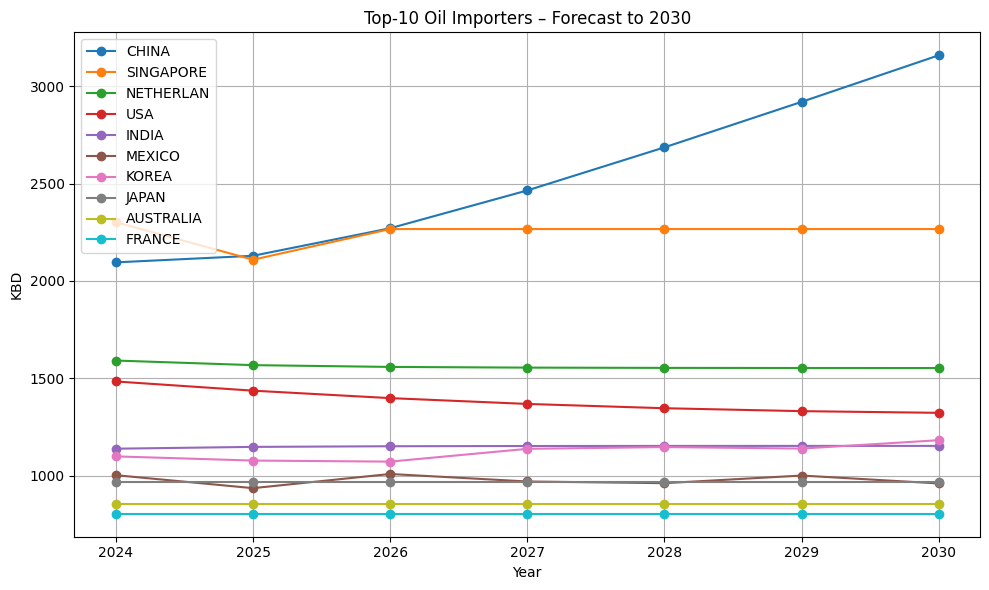

In [27]:
plt.figure(figsize=(10,6))

for r in forecast_results:
    plt.plot(r["forecast"].index, r["forecast"].values, marker="o", label=r["Country"])

plt.title("Top-10 Oil Importers – Forecast to 2030")
plt.xlabel("Year")
plt.ylabel("KBD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


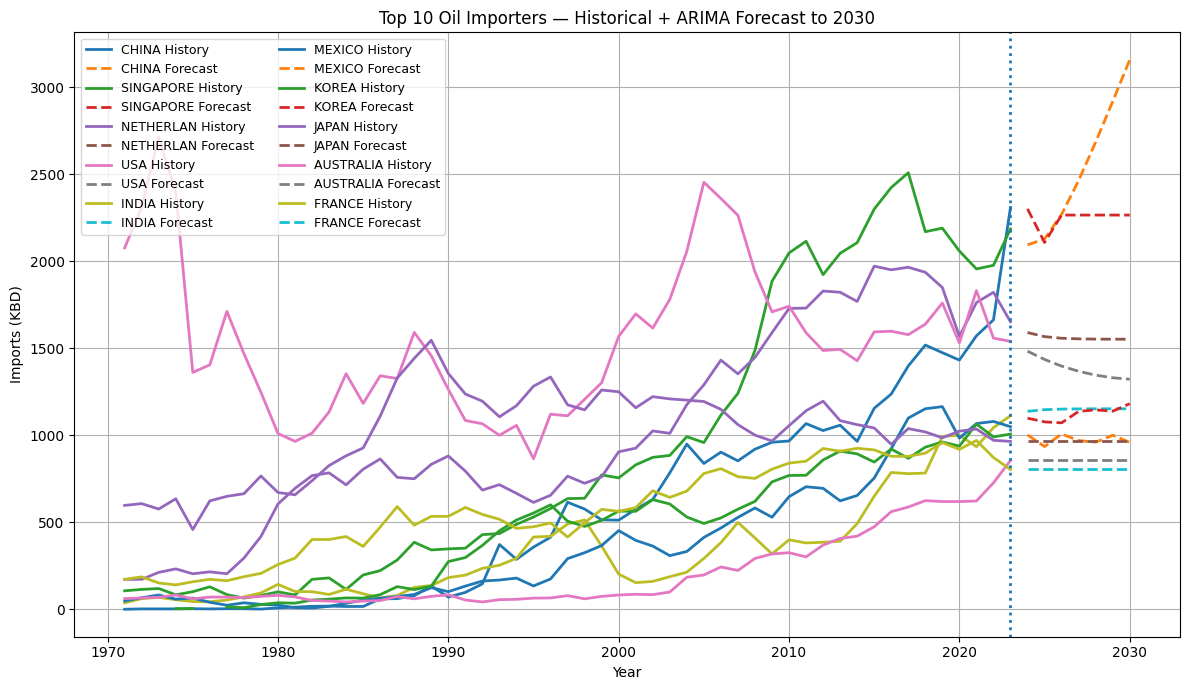

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for r in forecast_results:
    country = r["Country"]

    hist = r["ts"]
    fc = r["forecast"]

    # Historical (solid)
    plt.plot(hist.index, hist.values, linewidth=2, label=f"{country} History")

    # Forecast (dashed)
    plt.plot(fc.index, fc.values, linestyle="--", linewidth=2, label=f"{country} Forecast")

plt.title("Top 10 Oil Importers — Historical + ARIMA Forecast to 2030")
plt.xlabel("Year")
plt.ylabel("Imports (KBD)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.axvline(pd.Timestamp("2023-01-01"), linestyle=":", linewidth=2)
plt.tight_layout()
plt.show()


In [49]:
import plotly.graph_objects as go

fig = go.Figure()

countries = [r["Country"] for r in forecast_results]

for i, r in enumerate(forecast_results):
    hist = r["ts"]
    fc = r["forecast"]

    fig.add_trace(
        go.Scatter(
            x=hist.index,
            y=hist.values,
            mode="lines+markers",
            name=f"{r['Country']} History",
            visible=(i == 0)
        )
    )

    fig.add_trace(
        go.Scatter(
            x=fc.index,
            y=fc.values,
            mode="lines+markers",
            line=dict(dash="dash"),
            name=f"{r['Country']} Forecast",
            visible=(i == 0)
        )
    )

buttons = []

for i, country in enumerate(countries):
    vis = [False] * len(fig.data)
    vis[2*i] = True
    vis[2*i+1] = True

    buttons.append(
        dict(
            label=country,
            method="update",
            args=[
                {"visible": vis},
                {"title": f"{country} Oil Imports — History + Forecast to 2030"}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.02,
            y=1.3
        )
    ],
    title=f"{countries[0]} Refined Oil Imports — History + Forecast to 2030",
    title_x=0.5,   # <-- THIS centers the title
    xaxis_title="Year",
    yaxis_title="Imports (KBD)",
    hovermode="x unified"
)

fig.show()


In [51]:
import plotly.graph_objects as go

fig = go.Figure()

for r in forecast_results:
    hist = r["ts"]
    fc = r["forecast"]

    # Historical (solid)
    fig.add_trace(
        go.Scatter(
            x=hist.index,
            y=hist.values,
            mode="lines+markers",
            name=f"{r['Country']} History"
        )
    )

    # Forecast (dashed)
    fig.add_trace(
        go.Scatter(
            x=fc.index,
            y=fc.values,
            mode="lines+markers",
            line=dict(dash="dash"),
            name=f"{r['Country']} Forecast"
        )
    )

fig.update_layout(
    title="Top 10 Importers Refined Oil — History + Forecast to 2030",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Imports (KBD)",
    hovermode="x unified",
    width=1200,
    height=700,
    margin=dict(l=40, r=40, t=90, b=80)
)

fig.show()
